<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20ECO004.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

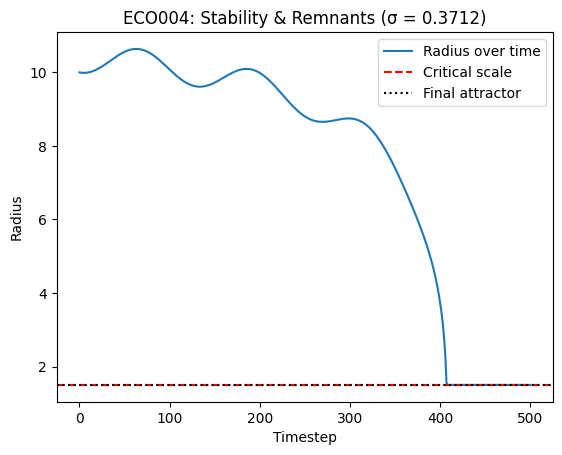

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
M1, M2 = 10.0, 8.0
alpha = 0.16
beta = 0.06
gamma = 0.2
R_c = 1.5
timesteps = 500
epsilon = 0.02  # perturbation amplitude

def S(R): return gamma * np.log(1 + R/R_c)
def collapse_step(R, M): return R - alpha * M / (R**2) + beta * S(R)

# Perturbation function (can be stochastic or sinusoidal)
def perturb(t): return epsilon * np.sin(0.05 * t)

# Simulate merger + perturbation
R_vals = [10.0]
M_total = M1 + M2
for t in range(timesteps):
    R_next = collapse_step(R_vals[-1], M_total) + perturb(t)
    R_next = max(R_next, R_c)
    R_vals.append(R_next)

# Stability metric
R_inf = R_vals[-1]
sigma = np.sqrt(np.mean([(r - R_inf)**2 for r in R_vals[-100:]]))

# Plot
plt.plot(R_vals, label="Radius over time")
plt.axhline(R_c, color='r', linestyle='--', label="Critical scale")
plt.axhline(R_inf, color='k', linestyle=':', label="Final attractor")
plt.xlabel("Timestep")
plt.ylabel("Radius")
plt.title(f"ECO004: Stability & Remnants (σ = {sigma:.4f})")
plt.legend()
plt.show()
